# E02 — Final Test and Error Analysis for the Pretrained Model

Run this notebook only after the official `main` training experiment in E01 has finished.

This notebook evaluates:

```text
outputs/pretrained/main/best_checkpoint.pth
```

on the independent test set and calculates:

- Top-1 accuracy
- Top-5 accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Confusion matrix
- Most frequently confused class pairs
- Prediction results for every test image

Do not repeatedly modify the model based on test-set results, because that would introduce test leakage.


## Step 1 — Import dependencies and locate the project directory


In [23]:
import csv
import json
import os
import sys
import time
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from torch import nn
from torchvision import transforms
from torchvision.models import resnet18
from tqdm.auto import tqdm


def find_project_root(start_path):
    """Search the current directory and its parents for the project root."""
    current = Path(start_path).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "src").exists()
            and (candidate / "data" / "processed").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "The project repository could not be found. "
        "Open this notebook from inside the repository."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data import create_dataloader, create_dataset


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_ROOT = Path(config.OUTPUT_ROOT) / "pretrained"
EXPERIMENT_NAME = "main"
EXPERIMENT_ROOT = OUTPUT_ROOT / EXPERIMENT_NAME

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Experiment:", EXPERIMENT_NAME)
print("Experiment root:", EXPERIMENT_ROOT)


Project root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group
Device: cuda
Experiment: main
Experiment root: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main


## Step 2 — Define the fixed test transform and model architecture

The test transform must match the deterministic validation transform used in E01.


In [24]:
def create_eval_transform():
    """Create the deterministic transform used for validation and testing."""
    image_size = config.IMG_SIZE[0]
    resize_size = int(image_size / 0.875)

    return transforms.Compose(
        [
            transforms.Resize(resize_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                config.IMG_MEAN,
                config.IMG_STD,
            ),
        ]
    )


def create_model():
    """Create the ResNet-18 architecture used during training."""
    model = resnet18(weights=None)
    model.fc = nn.Linear(
        model.fc.in_features,
        config.NUM_CLASSES,
    )
    return model


def calculate_topk(logits, labels, topk=(1, 5)):
    """Count correct predictions for each requested top-k value."""
    max_k = min(max(topk), logits.shape[1])
    predictions = logits.topk(max_k, dim=1).indices
    correct = predictions.eq(labels.view(-1, 1))

    results = {}

    for k in topk:
        current_k = min(k, logits.shape[1])
        results[k] = (
            correct[:, :current_k]
            .any(dim=1)
            .sum()
            .item()
        )

    return results


## Step 3 — Load category names


In [25]:
def load_label_names(manifest_path):
    """Load the label-to-category-name mapping from a CSV manifest."""
    label_names = {}

    with Path(manifest_path).open(
        "r",
        newline="",
        encoding="utf-8",
    ) as file:
        reader = csv.DictReader(file)

        for row in reader:
            label = int(row["label"])
            label_names[label] = row.get(
                "category_name",
                str(label),
            )

    return label_names


LABEL_NAMES = load_label_names(config.TRAIN_CSV)

if len(LABEL_NAMES) != config.NUM_CLASSES:
    raise RuntimeError(
        "The number of category names does not match config.NUM_CLASSES."
    )

print("Number of category names:", len(LABEL_NAMES))


Number of category names: 500


## Step 4 — Define output functions


In [26]:
def save_confusion_matrix(matrix, output_path):
    """Save and display a row-normalised confusion matrix overview."""
    row_sum = matrix.sum(axis=1, keepdims=True)

    normalised = np.divide(
        matrix,
        row_sum,
        out=np.zeros_like(matrix, dtype=float),
        where=row_sum != 0,
    )

    plt.figure(figsize=(10, 9))
    plt.imshow(
        normalised,
        interpolation="nearest",
        aspect="auto",
    )
    plt.title("Normalised Confusion Matrix Overview")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()


def save_confused_pairs(
    matrix,
    label_names,
    output_path,
    top_n=30,
):
    """Save the most frequent incorrect class pairs."""
    pairs = []

    for true_label in range(matrix.shape[0]):
        for pred_label in range(matrix.shape[1]):
            if true_label == pred_label:
                continue

            count = int(matrix[true_label, pred_label])

            if count > 0:
                pairs.append(
                    (count, true_label, pred_label)
                )

    pairs.sort(reverse=True)

    rows = []

    for rank, (
        count,
        true_label,
        pred_label,
    ) in enumerate(pairs[:top_n], start=1):
        rows.append(
            {
                "rank": rank,
                "count": count,
                "true_label": true_label,
                "true_name": label_names.get(
                    true_label,
                    str(true_label),
                ),
                "pred_label": pred_label,
                "pred_name": label_names.get(
                    pred_label,
                    str(pred_label),
                ),
            }
        )

    confused_pairs_df = pd.DataFrame(
        rows,
        columns=[
            "rank",
            "count",
            "true_label",
            "true_name",
            "pred_label",
            "pred_name",
        ],
    )

    confused_pairs_df.to_csv(
        output_path,
        index=False,
    )

    return confused_pairs_df


## Step 5 — Define checkpoint loading


In [27]:
def load_checkpoint_state_dict(checkpoint_path):
    """Load a model state dictionary from a trusted training checkpoint."""
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True,
        )

    except pickle.UnpicklingError:
        # This checkpoint was generated locally by E01 and is trusted.
        # It contains additional metadata such as TorchVersion.
        print(
            "The checkpoint contains trusted training metadata. "
            "Reloading with weights_only=False."
        )

        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

    except TypeError:
        # Compatibility fallback for older PyTorch versions.
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
        )

    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    ):
        state_dict = checkpoint["model_state_dict"]

    elif (
        isinstance(checkpoint, dict)
        and "state_dict" in checkpoint
    ):
        state_dict = checkpoint["state_dict"]

    elif isinstance(checkpoint, dict):
        state_dict = checkpoint

    else:
        raise TypeError(
            "Unsupported checkpoint format."
        )

    cleaned_state_dict = {}

    for key, value in state_dict.items():
        cleaned_key = key.removeprefix("module.")
        cleaned_state_dict[cleaned_key] = value

    return cleaned_state_dict

## Step 6 — Define the complete test evaluation


In [28]:
def evaluate_checkpoint(
    experiment_name="main",
    batch_size=64,
    num_workers=0,
):
    """Evaluate one trained experiment on the independent test set."""
    checkpoint_path = (
        OUTPUT_ROOT
        / experiment_name
        / "best_checkpoint.pth"
    )

    output_dir = (
        OUTPUT_ROOT
        / experiment_name
        / "test_results"
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}\n"
            "Finish E01 main training before running E02."
        )

    test_dataset = create_dataset(
        "test",
        image_root=config.DATA_RAW_ROOT,
        transform=create_eval_transform(),
    )

    if len(test_dataset) == 0:
        raise RuntimeError("The test dataset is empty.")

    if not hasattr(test_dataset, "samples"):
        raise AttributeError(
            "The test dataset must provide a samples attribute."
        )

    if len(test_dataset.samples) != len(test_dataset):
        raise RuntimeError(
            "test_dataset.samples does not match the dataset length."
        )

    test_loader = create_dataloader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=DEVICE.type == "cuda",
    )

    model = create_model()
    model.load_state_dict(
        load_checkpoint_state_dict(checkpoint_path)
    )
    model = model.to(DEVICE)
    model.eval()

    all_true = []
    all_pred = []
    prediction_rows = []

    total_top1 = 0
    total_top5 = 0
    total_samples = 0
    sample_index = 0

    print("Checkpoint:", checkpoint_path)
    print("Test images:", len(test_dataset))
    print("Batch size:", batch_size)
    print("DataLoader workers:", num_workers)

    start_time = time.perf_counter()

    with torch.inference_mode():
        for images, labels in tqdm(
            test_loader,
            desc=f"Testing {experiment_name}",
        ):
            images = images.to(
                DEVICE,
                non_blocking=True,
            )
            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)
            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            saved_topk = min(
                5,
                probabilities.shape[1],
            )

            top5_scores, top5_labels = (
                probabilities.topk(
                    saved_topk,
                    dim=1,
                )
            )

            predictions = top5_labels[:, 0]
            topk_results = calculate_topk(
                logits,
                labels,
            )

            total_top1 += topk_results[1]
            total_top5 += topk_results[5]
            total_samples += labels.shape[0]

            labels_cpu = labels.cpu().tolist()
            predictions_cpu = (
                predictions.cpu().tolist()
            )
            top5_labels_cpu = (
                top5_labels.cpu().tolist()
            )
            top5_scores_cpu = (
                top5_scores.cpu().tolist()
            )

            all_true.extend(labels_cpu)
            all_pred.extend(predictions_cpu)

            for batch_index in range(
                len(labels_cpu)
            ):
                file_path = str(
                    test_dataset.samples[
                        sample_index
                    ][0]
                )

                true_label = labels_cpu[batch_index]
                pred_label = predictions_cpu[
                    batch_index
                ]

                prediction_rows.append(
                    {
                        "file_path": file_path,
                        "true_label": true_label,
                        "true_name": LABEL_NAMES.get(
                            true_label,
                            str(true_label),
                        ),
                        "pred_label": pred_label,
                        "pred_name": LABEL_NAMES.get(
                            pred_label,
                            str(pred_label),
                        ),
                        "confidence": float(
                            top5_scores_cpu[
                                batch_index
                            ][0]
                        ),
                        "correct": int(
                            true_label == pred_label
                        ),
                        "top5_labels": " ".join(
                            str(value)
                            for value in top5_labels_cpu[
                                batch_index
                            ]
                        ),
                        "top5_scores": " ".join(
                            f"{value:.8f}"
                            for value in top5_scores_cpu[
                                batch_index
                            ]
                        ),
                    }
                )

                sample_index += 1

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    if total_samples == 0:
        raise RuntimeError(
            "No test samples were evaluated."
        )

    if sample_index != total_samples:
        raise RuntimeError(
            "Prediction row count does not match the evaluated sample count."
        )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            all_true,
            all_pred,
            labels=list(
                range(config.NUM_CLASSES)
            ),
            average="macro",
            zero_division=0,
        )
    )

    metrics = {
        "experiment": experiment_name,
        "top1": float(
            total_top1 / total_samples
        ),
        "top5": float(
            total_top5 / total_samples
        ),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(macro_f1),
        "test_images": int(total_samples),
        "true_classes": int(
            len(set(all_true))
        ),
        "predicted_classes": int(
            len(set(all_pred))
        ),
        "inference_seconds": float(
            elapsed_seconds
        ),
        "milliseconds_per_image": float(
            elapsed_seconds
            * 1000
            / total_samples
        ),
        "checkpoint": str(checkpoint_path),
    }

    metrics_path = output_dir / "metrics.json"
    predictions_path = (
        output_dir / "predictions.csv"
    )
    matrix_path = (
        output_dir / "confusion_matrix.npy"
    )
    matrix_image_path = (
        output_dir
        / "confusion_matrix_overview.png"
    )
    confused_pairs_path = (
        output_dir / "confused_pairs.csv"
    )

    with metrics_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metrics, file, indent=2)

    predictions_df = pd.DataFrame(
        prediction_rows
    )
    predictions_df.to_csv(
        predictions_path,
        index=False,
    )

    matrix = confusion_matrix(
        all_true,
        all_pred,
        labels=list(
            range(config.NUM_CLASSES)
        ),
    )

    np.save(matrix_path, matrix)

    save_confusion_matrix(
        matrix,
        matrix_image_path,
    )

    confused_pairs_df = save_confused_pairs(
        matrix,
        LABEL_NAMES,
        confused_pairs_path,
    )

    print("\nEvaluation metrics:")
    print(json.dumps(metrics, indent=2))

    print("\nSaved files:")
    for path in [
        metrics_path,
        predictions_path,
        matrix_path,
        matrix_image_path,
        confused_pairs_path,
    ]:
        print(path)

    return (
        metrics,
        predictions_df,
        confused_pairs_df,
    )


## Step 7 — Verify the official main checkpoint


In [29]:
MAIN_CHECKPOINT_PATH = (
    OUTPUT_ROOT
    / "main"
    / "best_checkpoint.pth"
)

print("Expected checkpoint:", MAIN_CHECKPOINT_PATH)
print("Checkpoint exists:", MAIN_CHECKPOINT_PATH.exists())

if not MAIN_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {MAIN_CHECKPOINT_PATH}\n"
        "Run E01 and finish the official main experiment first."
    )


Expected checkpoint: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main\best_checkpoint.pth
Checkpoint exists: True


## Step 8 — Evaluate the official main model

This cell is enabled by default.


The checkpoint contains trusted training metadata. Reloading with weights_only=False.
Checkpoint: C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main\best_checkpoint.pth
Test images: 5000
Batch size: 64
DataLoader workers: 0


Testing main: 100%|██████████| 79/79 [00:25<00:00,  3.12it/s]


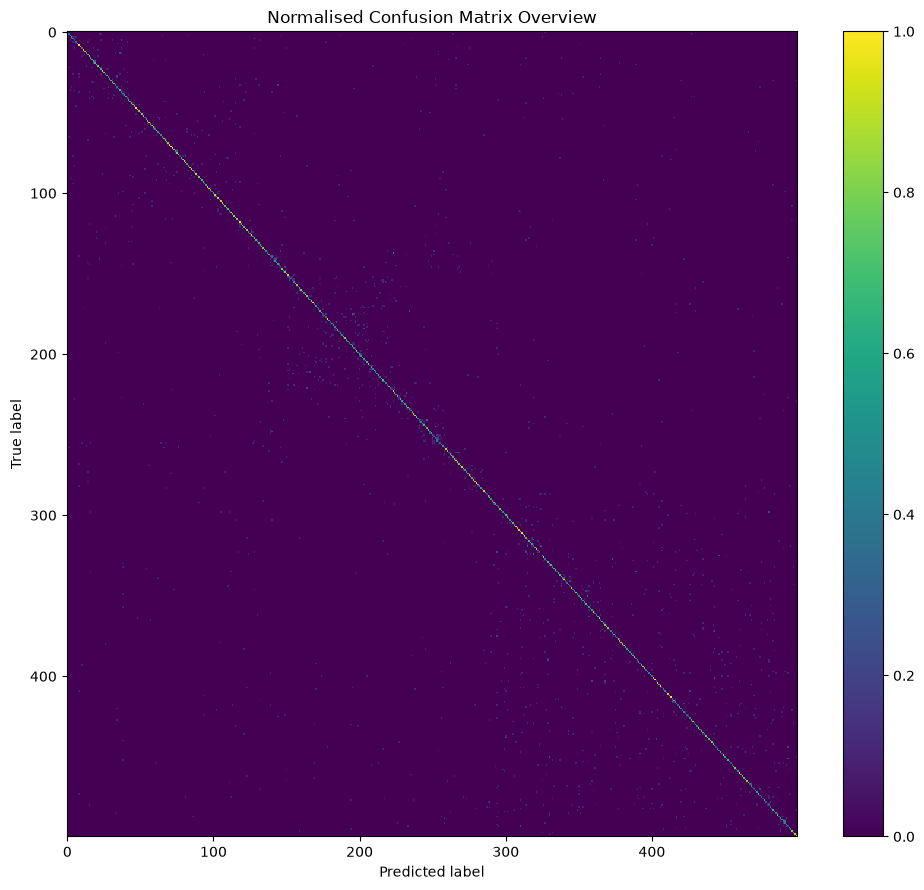


Evaluation metrics:
{
  "experiment": "main",
  "top1": 0.639,
  "top5": 0.841,
  "macro_precision": 0.662327015141721,
  "macro_recall": 0.639,
  "macro_f1": 0.6372546329664811,
  "test_images": 5000,
  "true_classes": 500,
  "predicted_classes": 500,
  "inference_seconds": 25.351389800000106,
  "milliseconds_per_image": 5.070277960000022,
  "checkpoint": "C:\\Users\\\u4f60\u597d\\Desktop\\comp9517\\9517_assignment_MVP_Group\\outputs\\pretrained\\main\\best_checkpoint.pth"
}

Saved files:
C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main\test_results\metrics.json
C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main\test_results\predictions.csv
C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main\test_results\confusion_matrix.npy
C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\outputs\pretrained\main\test_results\confusion_matrix_overview.png
C:\Users\你好\Desktop\comp9517\9517_assignment_MVP_Group\o

,rank,count,true_label,true_name,pred_label,pred_name
0,1,4,490,Pinus resinosa,491,Pinus virginiana
1,2,4,350,Packera tampicana,356,Senecio vernalis
2,3,4,324,Phalaris arundinacea,319,Calamagrostis canadensis
3,4,4,254,Urosaurus ornatus,253,Urosaurus nigricaudus
4,5,4,217,Amazona finschi,216,Amazona albifrons
5,6,4,137,Sphyraena barracuda,223,Triaenodon obesus
6,7,4,102,Lethe eurydice,101,Lethe appalachia
7,8,3,467,Ranunculus cassubicus,468,Ranunculus polyanthemos
8,9,3,416,Mimosa quadrivalvis,414,Mimosa nuttallii
9,10,3,339,Erigeron foliosus,340,Erigeron strigosus


In [30]:
RUN_MAIN_EVALUATION = True

if RUN_MAIN_EVALUATION:
    (
        main_metrics,
        main_predictions,
        main_confused_pairs,
    ) = evaluate_checkpoint(
        experiment_name="main",
        batch_size=64,
        num_workers=0,
    )

    display(main_confused_pairs.head(10))


## Step 9 — Optional ablation evaluations

Run these only after the corresponding E01 experiments have been trained.


In [31]:
RUN_ABLATION_EVALUATION = False

if RUN_ABLATION_EVALUATION:
    no_augmentation_metrics, _, _ = (
        evaluate_checkpoint(
            experiment_name="no_augmentation",
            batch_size=64,
            num_workers=0,
        )
    )

    head_only_metrics, _, _ = (
        evaluate_checkpoint(
            experiment_name="head_only",
            batch_size=64,
            num_workers=0,
        )
    )


## E02 Completion Requirements

The main experiment should contain:

```text
outputs/pretrained/main/test_results/
├── metrics.json
├── predictions.csv
├── confusion_matrix.npy
├── confusion_matrix_overview.png
└── confused_pairs.csv
```

E03 uses `predictions.csv` and `confused_pairs.csv`.
